In [1]:
!pip install numpy matplotlib

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [3]:
import time

def cpu_matrix_multiply(A, B):
    n = len(A)
    m = len(B[0])
    p = len(B)

    result = [[0 for _ in range(m)] for _ in range(n)]

    start = time.time()

    for i in range(n):
        for j in range(m):
            for k in range(p):
                result[i][j] += A[i][k] * B[k][j]

    end = time.time()

    return result, end - start

In [4]:
import time
import numpy as np

def accelerator_matrix_multiply(A, B):
    start = time.time()

    # Simulating parallel MAC using numpy
    result = np.dot(A, B)

    end = time.time()

    return result, end - start

In [5]:
import numpy as np

def generate_matrix(size):
    return np.random.randint(0, 10, (size, size))

In [6]:
import numpy as np

size = 200  # try different sizes later

A = generate_matrix(size)
B = generate_matrix(size)

# CPU
cpu_result, cpu_time = cpu_matrix_multiply(A.tolist(), B.tolist())

# Accelerator
acc_result, acc_time = accelerator_matrix_multiply(A, B)

print(f"CPU Time: {cpu_time:.4f} seconds")
print(f"Accelerator Time: {acc_time:.4f} seconds")

print(f"Speedup: {cpu_time / acc_time:.2f}x")

CPU Time: 1.4046 seconds
Accelerator Time: 0.0126 seconds
Speedup: 111.68x


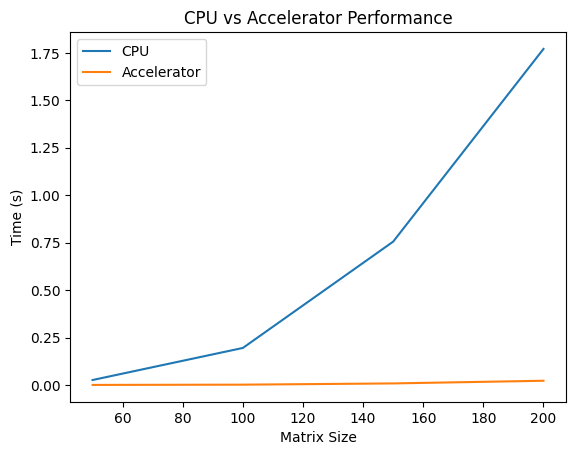

In [7]:
import matplotlib.pyplot as plt

sizes = [50, 100, 150, 200]
cpu_times = []
acc_times = []

for size in sizes:
    A = generate_matrix(size)
    B = generate_matrix(size)

    _, cpu_time = cpu_matrix_multiply(A.tolist(), B.tolist())
    _, acc_time = accelerator_matrix_multiply(A, B)

    cpu_times.append(cpu_time)
    acc_times.append(acc_time)

plt.plot(sizes, cpu_times, label="CPU")
plt.plot(sizes, acc_times, label="Accelerator")

plt.xlabel("Matrix Size")
plt.ylabel("Time (s)")
plt.title("CPU vs Accelerator Performance")
plt.legend()
plt.show()

In [8]:
# Check if both outputs are same
if np.allclose(cpu_result, acc_result):
    print("✅ Results match!")
else:
    print("❌ Mismatch in results!")

✅ Results match!


In [9]:
def take_input_matrix():
    n = int(input("Enter matrix size (n x n): "))
    print("Enter matrix row by row:")

    matrix = []
    for i in range(n):
        row = list(map(int, input().split()))
        matrix.append(row)

    return matrix

In [10]:
import numpy as np

# Define matrices directly to avoid interactive input for testing
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

# You can convert them to lists if cpu_matrix_multiply expects lists
# cpu_result, cpu_time = cpu_matrix_multiply(A.tolist(), B.tolist())
# acc_result, acc_time = accelerator_matrix_multiply(A, B)

print("Matrices defined successfully:")
print("A:", A)
print("B:", B)

Matrices defined successfully:
A: [[1 2]
 [3 4]]
B: [[5 6]
 [7 8]]


In [11]:
def read_matrix_from_file(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()

    n = int(lines[0])
    A = [list(map(int, lines[i+1].split())) for i in range(n)]

    B = [list(map(int, lines[i+2+n].split())) for i in range(n)]

    return A, B

In [12]:
# Create a dummy input.txt file for demonstration
with open("input.txt", "w") as f:
    f.write("2\n") # Matrix size 2x2
    f.write("3 6\n") # Matrix A, row 1
    f.write("5 7\n") # Matrix A, row 2
    f.write("12 7\n") # Matrix B, row 1
    f.write("9 7\n") # Matrix B, row 2

# Redefine the function with the fix within this cell to override the previous definition
def read_matrix_from_file(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()

    n = int(lines[0])
    A = [list(map(int, lines[i+1].split())) for i in range(n)]

    # FIX: Corrected index for matrix B
    B = [list(map(int, lines[n+1+i].split())) for i in range(n)]

    return A, B

A, B = read_matrix_from_file("input.txt")

print("Matrices read from file successfully:")
print("A:", np.array(A))
print("B:", np.array(B))

Matrices read from file successfully:
A: [[3 6]
 [5 7]]
B: [[12  7]
 [ 9  7]]


In [13]:
import numpy as np

# Convert CPU result to numpy for comparison
cpu_result_np = np.array(cpu_result)

print("\n===== RESULTS =====")

# 🔹 Matrix Output
print("\nResult Matrix (first 5x5 part):")
print(acc_result[:5][:5])   # avoids printing huge matrix

# 🔹 Time Output
print(f"\nCPU Time: {cpu_time:.4f} seconds")
print(f"Accelerator Time: {acc_time:.4f} seconds")

# 🔹 Speedup
print(f"Speedup: {cpu_time / acc_time:.2f}x")

# 🔹 Correctness Check
if np.allclose(cpu_result_np, acc_result):
    print("✅ Results match!")
else:
    print("❌ Results do NOT match!")


===== RESULTS =====

Result Matrix (first 5x5 part):
[[4563 4509 4574 4201 4682 4645 4374 4158 4602 4519 4550 4828 4650 4178
  4088 4495 4598 4413 4806 4670 4388 4512 4167 4670 4398 4262 4367 4485
  4242 4565 4303 4204 4235 4017 4463 4523 4463 4254 4302 4428 3958 4772
  4104 4126 3913 4258 4640 4549 4343 4227 4078 4936 4567 3728 4736 3968
  4378 4392 4515 4510 4394 4285 3938 4195 4250 4382 4476 4800 4195 4662
  4541 4755 4549 4052 4036 4326 4525 4513 4302 4448 4116 4568 4257 4629
  4389 4294 4446 4291 4374 4770 4405 4372 4300 4404 4139 4235 4534 4269
  4128 4650 4369 4302 4694 4261 4326 4116 4617 4376 4223 3950 4393 4261
  4320 3999 4482 4519 4189 4571 4312 4628 4185 4949 4376 3728 4670 3972
  4214 4527 4451 4102 4110 4137 4469 4352 4385 4529 4157 4434 4414 4365
  4719 4279 4422 4245 3907 4810 4115 4511 4271 4269 4631 4418 4221 4332
  4420 4243 4210 4577 4058 4044 4135 4527 4088 4331 4120 4497 4243 4398
  4579 4432 4380 4583 4257 4033 3954 4231 4169 4419 4387 4201 4961 4814
  4441 414

In [14]:
print("\n===== PERFORMANCE SUMMARY =====")
print(f"Matrix Size: {len(A)} x {len(B[0])}")
print(f"CPU Time: {cpu_time:.4f}s")
print(f"Accelerator Time: {acc_time:.4f}s")
print(f"Speedup: {cpu_time/acc_time:.2f}x")


===== PERFORMANCE SUMMARY =====
Matrix Size: 2 x 2
CPU Time: 1.7704s
Accelerator Time: 0.0222s
Speedup: 79.78x


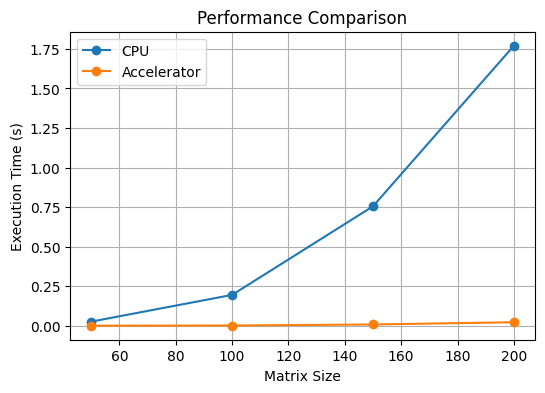

In [15]:
plt.figure(figsize=(6,4))
plt.plot(sizes, cpu_times, marker='o', label="CPU")
plt.plot(sizes, acc_times, marker='o', label="Accelerator")

plt.xlabel("Matrix Size")
plt.ylabel("Execution Time (s)")
plt.title("Performance Comparison")
plt.legend()
plt.grid()

plt.show()

In [16]:
import time
import numpy as np

def accelerator_with_mac_limit(A, B, mac_units=4):
    A = np.array(A)
    B = np.array(B)

    n, p = A.shape
    p, m = B.shape

    result = np.zeros((n, m))

    start = time.time()

    tasks = [(i, j) for i in range(n) for j in range(m)]

    # Process tasks in chunks (limited parallelism)
    for t in range(0, len(tasks), mac_units):
        batch = tasks[t:t + mac_units]

        for (i, j) in batch:
            result[i][j] = np.dot(A[i, :], B[:, j])

    end = time.time()

    return result, end - start

In [17]:
mac_units_list = [1, 2, 4, 8, 16]
times = []

for mac in mac_units_list:
    _, t = accelerator_with_mac_limit(A, B, mac_units=mac)
    times.append(t)
    print(f"MAC Units: {mac}, Time: {t:.4f}s")

MAC Units: 1, Time: 0.0028s
MAC Units: 2, Time: 0.0000s
MAC Units: 4, Time: 0.0000s
MAC Units: 8, Time: 0.0000s
MAC Units: 16, Time: 0.0000s


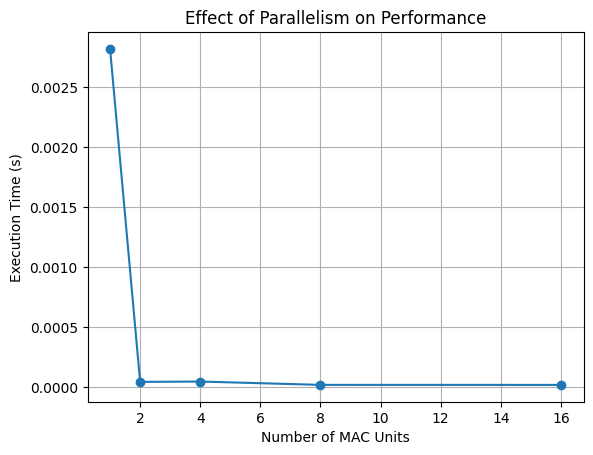

In [18]:
import matplotlib.pyplot as plt

plt.plot(mac_units_list, times, marker='o')
plt.xlabel("Number of MAC Units")
plt.ylabel("Execution Time (s)")
plt.title("Effect of Parallelism on Performance")
plt.grid()
plt.show()